Feather Scaling - Standardization

In [27]:
import numpy as np      # Numerical computing
import pandas as pd     # Data analysis
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns   # Statistical visualization

In [28]:
df = pd.read_csv('Social_Network_Ads.csv')

In [29]:
df=df.iloc[:,2:]

In [30]:
df.sample(4)

,Age,EstimatedSalary,Purchased
85,31,118000,1
88,26,81000,0
364,42,104000,1
196,30,79000,0


Train test split

In [31]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    df.drop('Purchased', axis=1),
    df['Purchased'],
    test_size=0.3,
    random_state=0
)

In [31]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    df.drop('Purchased', axis=1),
    df['Purchased'],
    test_size=0.3,
    random_state=0
)

StandardScaler

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler on the training set
scaler.fit(x_train)

# Transform the training and test sets
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [33]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [34]:
x_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [35]:
#it give us nupy array , which hard to undestand so
x_train_scaled

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

In [36]:
#To solve this to convert it in datafram
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [37]:
#as you see now it is scaled
x_train_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [38]:
np.round(x_train.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [39]:
np.round(x_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


Effects of Scalling

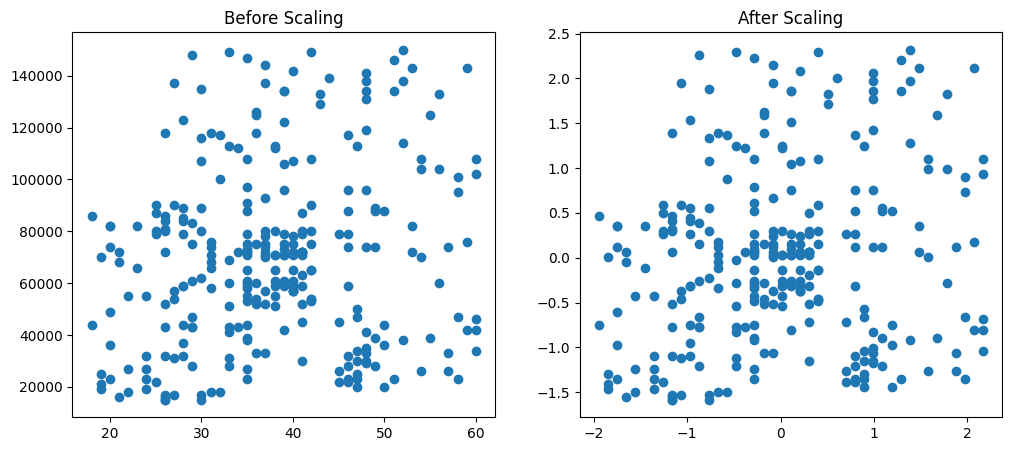

In [40]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before scaling
ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")

# After scaling
ax2.scatter(x_train_scaled['Age'], x_train_scaled['EstimatedSalary'])
ax2.set_title("After Scaling")

plt.show()

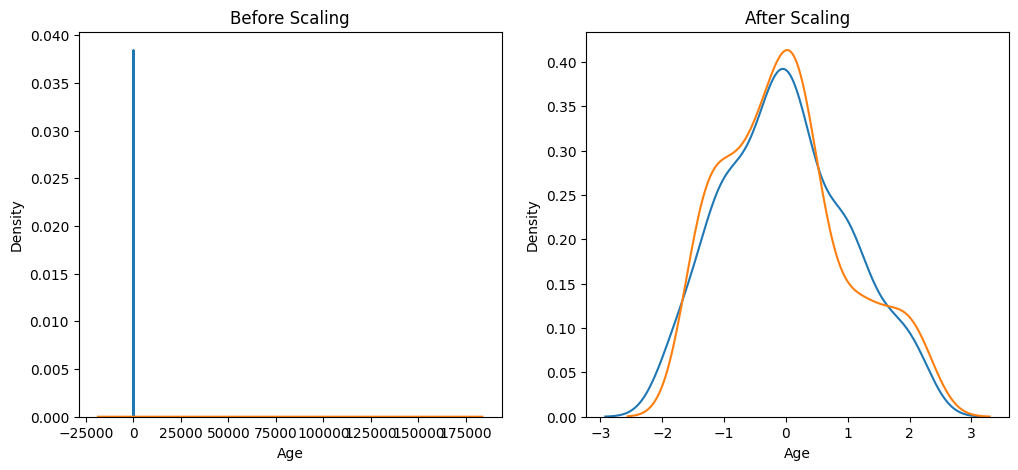

In [41]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before scaling
ax1.set_title("Before Scaling")
sns.kdeplot(x_train['Age'] , ax=ax1)
sns.kdeplot(x_train['EstimatedSalary'] , ax=ax1)

# After scaling
ax2.set_title("After Scaling")
sns.kdeplot(x_train_scaled['Age'] , ax=ax2)
sns.kdeplot(x_train_scaled['EstimatedSalary'] , ax=ax2)

plt.show()

Comparison of Distributions

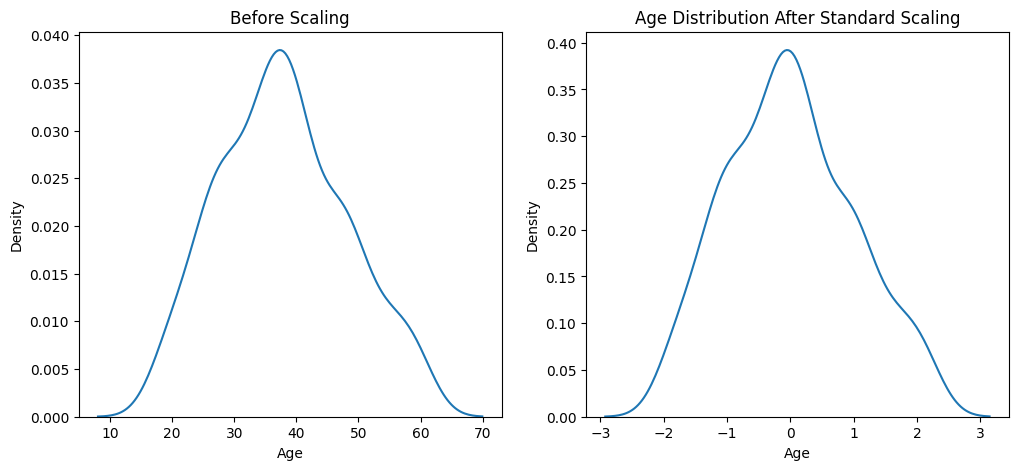

In [42]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before scaling
ax1.set_title("Before Scaling")
sns.kdeplot(x_train['Age'] , ax=ax1)

# After scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(x_train_scaled['Age'] , ax=ax2)

plt.show()

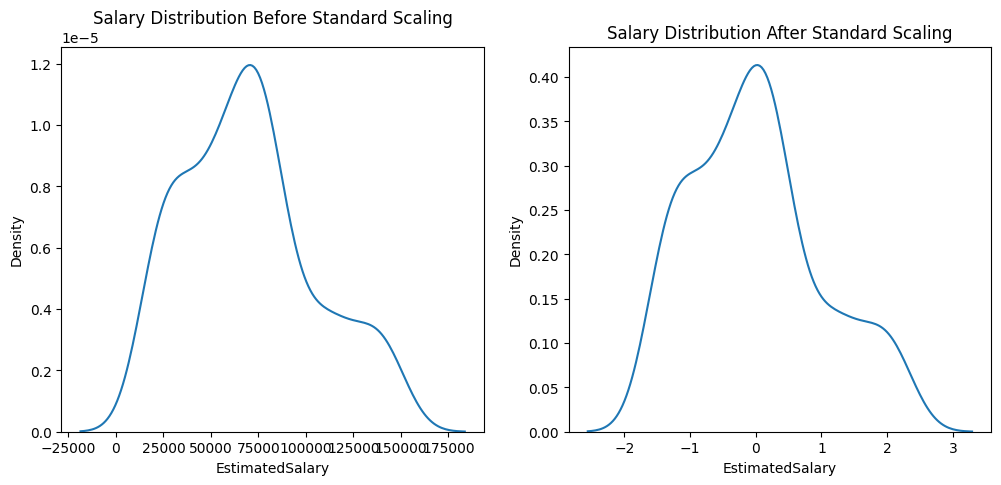

In [43]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before scaling
ax1.set_title('Salary Distribution Before Standard Scaling')
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)

# After scaling
ax2.set_title('Salary Distribution After Standard Scaling')
sns.kdeplot(x_train_scaled['EstimatedSalary'], ax=ax2)

plt.show()

Why Scaling is important?

In [51]:
from sklearn.linear_model import LogisticRegression

# Create instances of LogisticRegression models
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [58]:
# Now you can fit the models (assuming your data variables are already defined)
r.fit(x_train, y_train)
r_scaled.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [59]:
# First, fit/train the models with training data before making predictions
lr.fit(x_train, y_train)  # Train the regular logistic regression model
lr_scaled.fit(x_train_scaled, y_train)  # Train the scaled logistic regression model

# Now you can make predictions with the fitted models
y_pred = lr.predict(x_test)
y_pred_scaled = lr_scaled.predict(x_test_scaled)

In [60]:
from sklearn.metrics import accuracy_score

In [61]:
print('Actual' , accuracy_score(y_test , y_pred))
print('Scaled' , accuracy_score(y_test , y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


In [62]:
from sklearn.tree import DecisionTreeClassifier

In [63]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [64]:
dt.fit(x_train , y_train)
dt_scaled.fit(x_train_scaled , y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [65]:
y_pre = dt.predict(x_test)
y_pre_scaled = dt_scaled.predict(x_test_scaled)

In [66]:
print('Actual' , accuracy_score(y_test , y_pred))
print('Scaled' , accuracy_score(y_test , y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


In [67]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


Effect of Outlier

In [72]:
df = pd.concat([df,pd.DataFrame({
        'Age': [5, 90, 95],
        'EstimatedSalary': [1000, 2000, 35000],
        'Purchased': [0, 1, 1]
    })
], ignore_index=True)

In [73]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
401,90,2000,1
402,95,35000,1
403,5,1000,0
404,90,2000,1


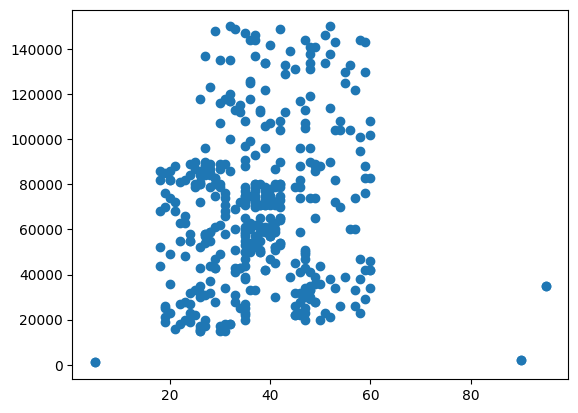

In [74]:
plt.scatter(df['Age'] , df['EstimatedSalary'])

In [75]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    df.drop('Purchased', axis=1),
    df['Purchased'],
    test_size=0.3,
    random_state=0
)

x_train.shape , x_test.shape

((284, 2), (122, 2))

In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler on the training set
scaler.fit(x_train)

# Transform the training and test sets
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [77]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

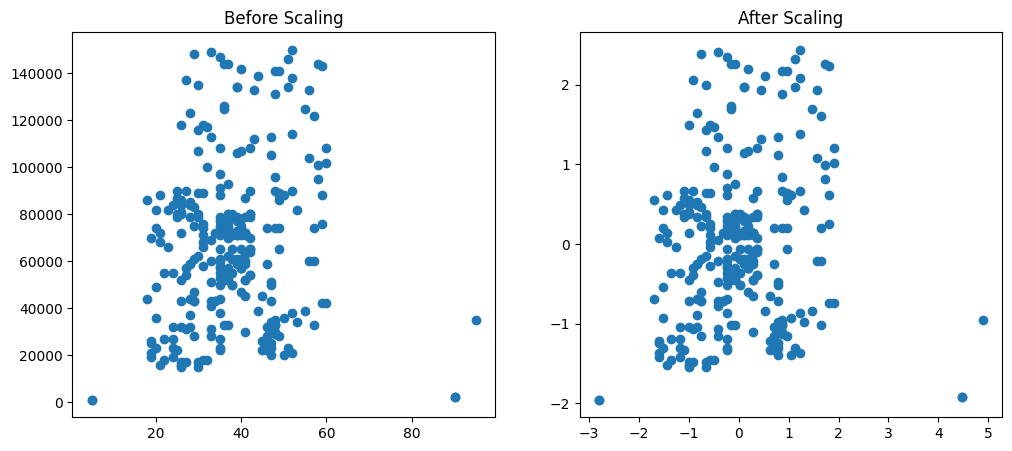

In [78]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before scaling
ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")

# After scaling
ax2.scatter(x_train_scaled['Age'], x_train_scaled['EstimatedSalary'])
ax2.set_title("After Scaling")

plt.show()